## Learning Linearvariate Regression on Salary data from Scratch as well as Sklearn 

In [1]:
#importing different libraries as required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Salary_dataset.csv')
df.head()


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [3]:
#checking if there is any null data
df.isnull().sum()
#From this we can see that there is no null data in the dataset

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [4]:
#Dropping the 'Unnamed' column as it doesnt make any sense in our dataset

df.drop('Unnamed: 0', axis=1, inplace= True)

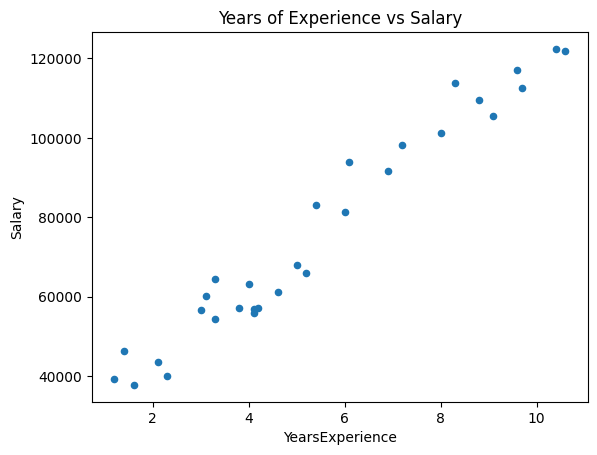

In [5]:
#Plotting our data to see the distribution of the publish_display_data
df.plot(kind='scatter', x='YearsExperience', y='Salary', title='Years of Experience vs Salary')
plt.show()

In [6]:
#Class Defination 
class UnivariateRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate=learning_rate
        self.n_iters=n_iters
        self.theta=None
        self.MSE_loss_history=[]
        self.theta_history=[]
        
    def MSE_loss(self, y_pred, y):
        m=y.shape[0] #gives number of samples
        loss=(1/(2*m))*np.sum((y_pred - y)**2)
        return loss#formula to calulcateloss
    
    def gradient_descent(self, X, y, y_pred, theta):
        m=y.shape[0]
        gradient_0=np.sum(y_pred -y)/m
        gradient_1 = np.sum(np.dot((y_pred-y).T, X[:,1])/m)
        
         # Update parameters
         # Here theta[0] is the intercept
         # Here theta[1] is the slope
        theta[0] = theta[0] - self.learning_rate * gradient_0
        theta[1] = theta[1] - self.learning_rate * gradient_1
        return theta
    def fit(self, X: np.ndarray, y:np.ndarray) -> np.ndarray:
        """
        Reshape the input X and train the model

        Args:
            X (np.ndarray): Input feature matrix of dimension (n_samples, n_features)
            y (np.ndarray): Label matrix of dimension (n_samples, 1)

        Returns:
            np.ndarray: Parameter: theta matrix of dimension (n_features+1, 1)
        """
        # Add new dimension to X
        #np.ones((X.shape[0], 1)) creates a column vector (2D array) of ones with the same number of rows as X and 1 column
        #np.hstack means horizontal stacking, i.e., concatenating arrays side-by-side
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        #Y= theta0 x 1 + theta1 x X
        # Initialize theta
        self.theta = np.zeros((X.shape[1], 1))
        
        # Training loop
        #Each iteration is one step of gradient descent to update parameters and minimize the loss.

        for i in range(self.n_iters):
            #This is a matrix multiplication between the feature matrix X and the parameter vector theta.
            
            y_pred = np.dot(X, self.theta)
            # compute loss
            loss = self.MSE_loss(y_pred, y)
            #Calculate the Mean Squared Error (MSE) loss, which measures how well the model predictions fit the actual labels y.
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)
            
            #Logs the current loss every 100 iterations so you can see how the model is learning over time.
            if i % 100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss}")
            #Calls the gradient descent method to calculate gradients of the loss with respect to parameters and update theta accordingly.
            
            # use gradient descent
            self.theta = self.gradient_descent(X, y, y_pred, self.theta)
        
        return self.theta
    #generates predictions for new input data X using the learned parameters theta.

    def predict(self, X: np.ndarray, theta: np.ndarray) -> np.ndarray:
        # This function assumes that X has been normalized
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        #Performs matrix multiplication between X and theta:
        predictions = np.dot(X, theta)
        #Returns the predicted values as a numpy array.
        return predictions
    
    def mean_absolute_error(self, y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def mean_squared_error(self,y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def root_mean_squared_error(self,y_true, y_pred):
        mse = np.mean((y_true - y_pred) ** 2)
        return mse

    def r2_score(self,y_true, y_pred):
        ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
        ss_residual = np.sum((y_true - y_pred) ** 2)
        return 1 - (ss_residual / ss_total)


In [7]:
#defining values
X= df['YearsExperience'].values
y= df['Salary'].values


In [8]:
# Reshaping X and y
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (30, 1)
Shape of y:  (30, 1)


In [9]:

myModel = UnivariateRegression(learning_rate=0.05, n_iters=5000)
theta = myModel.fit(X, y)

Iteration 0: MSE Loss = 3251553638.866667
Iteration 100: MSE Loss = 22652215.141705874
Iteration 200: MSE Loss = 16524759.20923579
Iteration 300: MSE Loss = 15748181.337409716
Iteration 400: MSE Loss = 15649759.862306451
Iteration 500: MSE Loss = 15637286.178580794
Iteration 600: MSE Loss = 15635705.296100382
Iteration 700: MSE Loss = 15635504.939135121
Iteration 800: MSE Loss = 15635479.546410464
Iteration 900: MSE Loss = 15635476.328202097
Iteration 1000: MSE Loss = 15635475.920334663
Iteration 1100: MSE Loss = 15635475.868642591
Iteration 1200: MSE Loss = 15635475.862091279
Iteration 1300: MSE Loss = 15635475.86126099
Iteration 1400: MSE Loss = 15635475.861155743
Iteration 1500: MSE Loss = 15635475.861142417
Iteration 1600: MSE Loss = 15635475.861140726
Iteration 1700: MSE Loss = 15635475.861140512
Iteration 1800: MSE Loss = 15635475.861140482
Iteration 1900: MSE Loss = 15635475.861140475
Iteration 2000: MSE Loss = 15635475.861140482
Iteration 2100: MSE Loss = 15635475.861140477
Ite

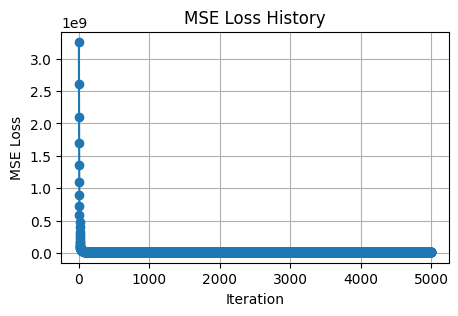

In [10]:
loss_history = myModel.MSE_loss_history

plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker='o')  # line plot with dots on points
plt.title("MSE Loss History")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

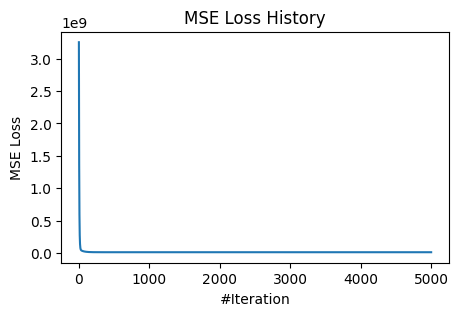

In [11]:
# Plotting Learning Curve
import seaborn as sns
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

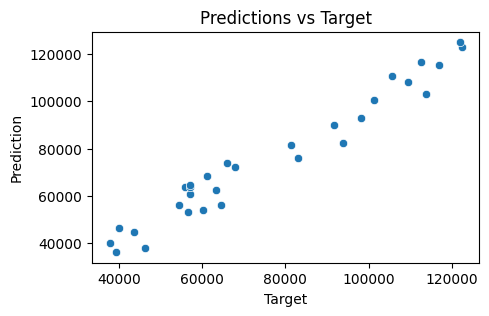

In [12]:
predictions = myModel.predict(X, theta)
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y[:, 0], y=predictions[:, 0])
plt.title("Predictions vs Target")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.show()

In [13]:
#Creating train test split usinf Sklearn
from sklearn.model_selection import train_test_split
myModel = UnivariateRegression(learning_rate=0.01, n_iters=1000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train on training data
theta = myModel.fit(X_train, y_train)



Iteration 0: MSE Loss = 3135614129.3541665
Iteration 100: MSE Loss = 50593271.58168006
Iteration 200: MSE Loss = 37198797.8484245
Iteration 300: MSE Loss = 28647777.92377717
Iteration 400: MSE Loss = 23188814.532765
Iteration 500: MSE Loss = 19703817.238054566
Iteration 600: MSE Loss = 17478998.115043886
Iteration 700: MSE Loss = 16058675.59782792
Iteration 800: MSE Loss = 15151942.986602956
Iteration 900: MSE Loss = 14573085.707151802


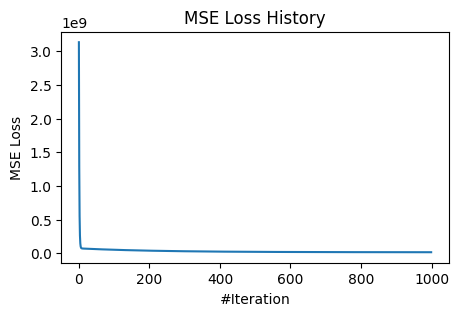

In [14]:
import seaborn as sns
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [15]:
y_pred_test = myModel.predict(X_test, theta)

In [16]:

#training Using the Sklearn Linear Regression Model
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)



LinearRegression()

In [17]:
y_pred_sk = sk_model.predict(X_test)

In [19]:
mae = myModel.mean_absolute_error(y_test, y_pred_test)
mse = myModel.mean_squared_error(y_test, y_pred_test)
rmse = myModel.root_mean_squared_error(y_test, y_pred_test)
r2 = myModel.r2_score(y_test, y_pred_test)

print(f"{'Manual Model Evaluation':<30} {'Sklearn Model Evaluation':<30}")
print(f"{'-'*30} {'-'*30}")
print(f"{'MAE  = ' + format(mae, '.2f'):<30} MAE  = {myModel.mean_absolute_error(y_test, y_pred_sk):.2f}")
print(f"{'MSE  = ' + format(mse, '.2f'):<30} MSE  = {myModel.mean_squared_error(y_test, y_pred_sk):.2f}")
print(f"{'RMSE = ' + format(rmse, '.2f'):<30} RMSE = {myModel.root_mean_squared_error(y_test, y_pred_sk):.2f}")
print(f"{'R²   = ' + format(r2, '.4f'):<30} R²   = {myModel.r2_score(y_test, y_pred_sk):.4f}")


Manual Model Evaluation        Sklearn Model Evaluation      
------------------------------ ------------------------------
MAE  = 6374.02                 MAE  = 6286.45
MSE  = 52872110.11             MSE  = 49830096.86
RMSE = 52872110.11             RMSE = 49830096.86
R²   = 0.8965                  R²   = 0.9024
